# GPT-2 Large — Embedding & Cluster Analysis
Chronis & Erk multi-prototype method applied to GPT-2 Large. Produces CSVs consumed by `Main_Project_Notebook.ipynb`.

In [5]:
import os
import csv
import pickle
import torch
import sys
sys.path.insert(0, 'src')
import datasets

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import spearmanr
from tqdm.auto import tqdm
from sklearn.exceptions import ConvergenceWarning
import warnings
warnings.filterwarnings("ignore", category=ConvergenceWarning)

## SimLex-999 — Similarity

In [2]:
print(torch.cuda.is_available())

True


In [3]:
from transformers import AutoConfig, AutoTokenizer, AutoModel

MODEL_DIR = Path("models/gpt2-large-hf")
source = str(MODEL_DIR) if MODEL_DIR.exists() else "gpt2-large"

tokenizer = AutoTokenizer.from_pretrained(source)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModel.from_pretrained(source)
model.eval()
model = model.to("cuda" if torch.cuda.is_available() else "cpu")

config = model.config
NUM_LAYERS = config.num_hidden_layers
print(f"Source: {source}")
print(f"Layers: {NUM_LAYERS}")
print(f"Hidden Size: {config.hidden_size}")

Loading weights:   0%|          | 0/436 [00:00<?, ?it/s]

Source: D:\252 Project\models\gpt2-large-hf
Layers: 36
Hidden Size: 1280


In [4]:
simlex999 = datasets.get_simlex999()
simlex999_wordlist = list(set(
    [row["word1"] for row in simlex999] + [row["word2"] for row in simlex999]
))
display(simlex999)

processed 999 word pairs from simlex999 dataset


[{'word1': 'old',
  'word2': 'new',
  'POS': 'A',
  'SimLex999': '1.58',
  'conc_w1': 2.72,
  'conc_w2': 2.81,
  'concQ': '2',
  'assoc_USF': '7.25',
  'sim_assoc333': '1',
  'SD_simlex': '0.41',
  'similarity': 1.58},
 {'word1': 'smart',
  'word2': 'intelligent',
  'POS': 'A',
  'SimLex999': '9.2',
  'conc_w1': 1.75,
  'conc_w2': 2.46,
  'concQ': '1',
  'assoc_USF': '7.11',
  'sim_assoc333': '1',
  'SD_simlex': '0.67',
  'similarity': 9.2},
 {'word1': 'hard',
  'word2': 'difficult',
  'POS': 'A',
  'SimLex999': '8.77',
  'conc_w1': 3.76,
  'conc_w2': 2.21,
  'concQ': '2',
  'assoc_USF': '5.94',
  'sim_assoc333': '1',
  'SD_simlex': '1.19',
  'similarity': 8.77},
 {'word1': 'happy',
  'word2': 'cheerful',
  'POS': 'A',
  'SimLex999': '9.55',
  'conc_w1': 2.56,
  'conc_w2': 2.34,
  'concQ': '1',
  'assoc_USF': '5.85',
  'sim_assoc333': '1',
  'SD_simlex': '2.18',
  'similarity': 9.55},
 {'word1': 'hard',
  'word2': 'easy',
  'POS': 'A',
  'SimLex999': '0.95',
  'conc_w1': 3.76,
  'conc_

## BNC Corpus Setup

The British National Corpus (BNC) provides naturally occurring sentences for each target word. We cap at `MAX_SENTENCES=20` per word (reduced from 100 to keep memory manageable — a 100-sentence pkl came out at ~14 GB). The corpus is shuffled before collection to avoid ordering effects from the BNC's document structure.

In [5]:
import sys
sys.path.insert(0, 'src')
import datasets

def load_bnc():
    from nltk.corpus.reader import bnc
    bnc_reader = bnc.BNCCorpusReader(root='./data/BNC/Texts/', fileids=r'[A-K]/\w*/\w*\.xml')
    return bnc_reader #.tagged_sents()

In [6]:
def randomly(seq):
    import random
    shuffled = list(seq)
    random.shuffle(shuffled)
    return list(shuffled)

In [7]:
BNC_SIMLEX_PKL = 'bnc_examples.pkl'

def collect_bnc_examples(wordlist, max_num_examples=100):
    bnc_reader = datasets.get_bnc()
    print("BNC reader initialized, loading corpus...")
    corpus = bnc_reader.tagged_sents(strip_space=True)
    corpus_length = len(corpus)
    print(f"Corpus loaded: {corpus_length} sentences")

    unigrams = {word: max_num_examples for word in wordlist}
    bnc_examples = {word: [] for word in wordlist}
    randomized_indexes = randomly(list(range(corpus_length - 1)))

    with tqdm(total=len(randomized_indexes), desc="BNC sentences") as pbar:
        while unigrams and randomized_indexes:
            sentence = corpus[randomized_indexes.pop()]
            pbar.update(1)
            pbar.set_postfix(words_remaining=len(unigrams))
            for word_tuple in sentence:
                word = word_tuple[0]
                if unigrams.get(word) and unigrams[word] > 0:
                    bnc_examples[word].append(' '.join([w[0] for w in sentence]))
                    unigrams[word] -= 1
                    if unigrams[word] == 0:
                        del unigrams[word]
    return bnc_examples

if os.path.exists(BNC_SIMLEX_PKL):
    with open(BNC_SIMLEX_PKL, 'rb') as f:
        bnc_examples = pickle.load(f)
    print(f"Loaded {BNC_SIMLEX_PKL}: {len(bnc_examples)} words")
else:
    bnc_examples = collect_bnc_examples(simlex999_wordlist)
    with open(BNC_SIMLEX_PKL, 'wb') as f:
        pickle.dump(bnc_examples, f)
    print(f"Saved {BNC_SIMLEX_PKL}")

Loaded bnc_examples.pkl: 1028 words


In [8]:
warnings.filterwarnings("ignore", category=RuntimeWarning)

GPT2_SIMLEX_PKL = 'all_layer_outputs_individual_gpt2_simlex.pkl'
BATCH_SIZE = 16
MAX_SENTENCES = 20

def embed_words_batched(wordlist, bnc_examples, model, tokenizer,
                        batch_size=BATCH_SIZE, checkpoint_path=None, checkpoint_every=50):
    if checkpoint_path and os.path.exists(checkpoint_path):
        try:
            with open(checkpoint_path, 'rb') as f:
                all_outputs = pickle.load(f)
            print(f"Resuming: {len(all_outputs)} words already done")
        except EOFError:
            print(f"Checkpoint {checkpoint_path} is corrupt, starting fresh")
            all_outputs = {}
    else:
        all_outputs = {}

    remaining = [w for w in wordlist if w not in all_outputs]
    print(f"Words to process: {len(remaining)}/{len(wordlist)}")

    for n, word in enumerate(tqdm(remaining, desc="Embedding words")):
        sentences = [s for s in bnc_examples.get(word, []) if word in s][:MAX_SENTENCES]
        word_vectors = []

        for i in range(0, len(sentences), batch_size):
            batch = sentences[i : i + batch_size]
            enc = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=1024,
                return_offsets_mapping=True,
            )
            offset_mapping = enc.pop("offset_mapping")

            batch_token_indices = []
            for j, sentence in enumerate(batch):
                word_start = sentence.index(word)
                word_end = word_start + len(word)
                indices = [
                    idx for idx, (tok_s, tok_e) in enumerate(offset_mapping[j].tolist())
                    if tok_s < word_end and tok_e > word_start and tok_s < tok_e
                ]
                batch_token_indices.append(indices)

            inputs = {k: v.to(model.device) for k, v in enc.items()}
            with torch.no_grad():
                model_output = model(**inputs, output_hidden_states=True)

            for j, indices in enumerate(batch_token_indices):
                if not indices:
                    continue
                layer_vecs = torch.stack([
                    layer_hidden[j, indices, :].mean(dim=0).cpu()
                    for layer_hidden in model_output.hidden_states
                ]).half()
                if not layer_vecs.isnan().any():
                    word_vectors.append(layer_vecs)

        if word_vectors:
            all_outputs[word] = torch.stack(word_vectors)

        if checkpoint_path and (n + 1) % checkpoint_every == 0:
            with open(checkpoint_path, 'wb') as f:
                pickle.dump(all_outputs, f)
            tqdm.write(f"Checkpoint saved ({len(all_outputs)} words)")

    if checkpoint_path:
        with open(checkpoint_path, 'wb') as f:
            pickle.dump(all_outputs, f)

    return all_outputs


all_layer_outputs_individual = embed_words_batched(
    simlex999_wordlist, bnc_examples, model, tokenizer,
    checkpoint_path=GPT2_SIMLEX_PKL,
)
print("Done. Saved to", GPT2_SIMLEX_PKL)

Resuming: 1028 words already done
Words to process: 0/1028


Embedding words: 0it [00:00, ?it/s]

Done. Saved to all_layer_outputs_individual_gpt2_simlex.pkl


## K-Means Clustering and MaxSim

In [9]:
#Slice out per-layer matrix. Function to be used for computing MaxSim of two word clusters:
import sklearn
from sklearn.cluster import KMeans

def get_word_clusters(word, layer_idx, K=4, outputs=None):
    if outputs is None:
        outputs = all_layer_outputs_individual
    X = outputs[word][:, layer_idx, :].float().cpu().numpy()
    k = min(K, X.shape[0])
    kmeans = KMeans(n_clusters=k).fit(X)
    return kmeans.cluster_centers_  # (k, 1280)


In [10]:
#Compute MaxSim

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def max_sim(word1, word2, layer_idx, K=4, outputs=None):
    centroids1 = get_word_clusters(word1, layer_idx, K, outputs=outputs)
    centroids2 = get_word_clusters(word2, layer_idx, K, outputs=outputs)
    sims = [
        cosine_similarity(c1, c2)
        for c1 in centroids1
        for c2 in centroids2
    ]
    return max(sims)


### Per-layer Spearman ρ at Fixed K=4

Before the full K × layer sweep, we run K=4 across all 37 layers as a quick check of the layer-by-layer trend. GPT-2 Large typically peaks around the middle layers for semantic tasks.

In [11]:
#compute maxsim between word pairs per layer

results = []
skipped = []

for row in tqdm(simlex999, desc="Word pairs"):
    w1, w2 = row['word1'], row['word2']
    if w1 not in all_layer_outputs_individual or w2 not in all_layer_outputs_individual:
        skipped.append((w1, w2))
        continue

    layer_scores = []
    for layer_idx in range(37):
        score = max_sim(w1, w2, layer_idx, K=4)
        layer_scores.append(score)

    results.append({
        'word1': w1,
        'word2': w2,
        'simlex_score': float(row['SimLex999']),
        'layer_scores': layer_scores,
    })

print(f"Computed {len(results)} pairs, skipped {len(skipped)}")

Word pairs:   0%|          | 0/999 [00:00<?, ?it/s]

Computed 999 pairs, skipped 0


In [12]:
valid_pairs = [
    (row['word1'], row['word2'], float(row['SimLex999']))
    for row in simlex999
    if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
]
print(f"Valid pairs: {len(valid_pairs)}/999")

human_similarities = [s for _, _, s in valid_pairs]

for layer_idx in tqdm(range(37), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4) for w1, w2, _ in valid_pairs]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, human_similarities)}")

Valid pairs: 999/999


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.2302321600096601), pvalue=np.float64(1.7448952570656575e-13))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.35194818072090184), pvalue=np.float64(1.6750111931155103e-30))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.3773366823410273), pvalue=np.float64(3.7147699921807053e-35))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4104011508587096), pvalue=np.float64(7.19359487256564e-42))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.4266341010637472), pvalue=np.float64(1.8776269900989362e-45))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.45224018847535424), pvalue=np.float64(1.6173535558872845e-51))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.47206144103934616), pvalue=np.float64(1.3991934746572923e-56))
Layer 7 Spea

### SimLex-999 — K × Layer Heatmap

Spearman's ρ for every combination of K ∈ {1…8} clusters and all 37 layers (layer 0 = token embedding, layers 1–36 = transformer blocks). Results are cached to `results_gpt2_simlex.csv` after the first run — re-running the cell just loads the CSV and redraws the plot.

Loaded results/results_gpt2_simlex.csv


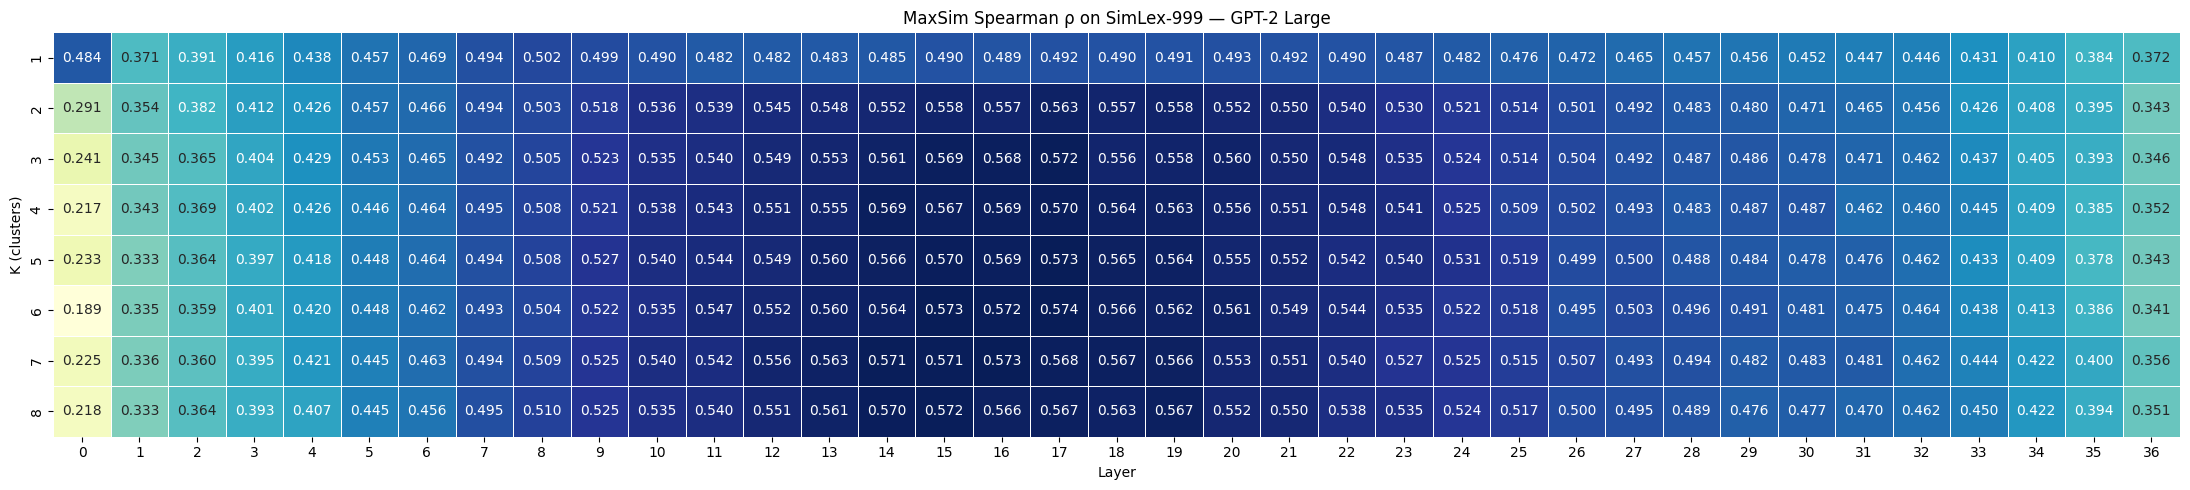

In [8]:
GPT2_SIMLEX_CSV = 'results/results_gpt2_simlex.csv'

if os.path.exists(GPT2_SIMLEX_CSV):
    df_heat = pd.read_csv(GPT2_SIMLEX_CSV, index_col=0)
    df_heat.columns = df_heat.columns.astype(int)
    print(f"Loaded {GPT2_SIMLEX_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]

    valid_pairs = [
        (row['word1'], row['word2'])
        for row in simlex999
        if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
    ]
    human_sims = [
        float(row['SimLex999'])
        for row in simlex999
        if row['word1'] in all_layer_outputs_individual and row['word2'] in all_layer_outputs_individual
    ]
    print(f"Valid pairs: {len(valid_pairs)}/999")

    heatmap_data = []
    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(NUM_LAYERS + 1), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K) for w1, w2 in valid_pairs]
            rho, _ = spearmanr(model_scores, human_sims)
            heatmap_data.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat = pd.DataFrame(heatmap_data).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat.to_csv(GPT2_SIMLEX_CSV)
    print(f"Saved {GPT2_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(df_heat, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False, cbar=False)
ax.set_title('MaxSim Spearman ρ on SimLex-999 — GPT-2 Large')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.savefig('results/gpt2_simlex_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## MEN Relatedness Dataset

MEN contains 3,000 word pairs rated for *relatedness* rather than similarity — related words share a domain or tend to co-occur but need not be interchangeable in context. Words already embedded for SimLex-999 are reused; only the novel MEN words need new BNC collection and embedding, then merged into a combined vocabulary.

In [14]:
# Load MEN dataset and identify words not yet in all_layer_outputs_individual
men = datasets.get_men()

men_wordlist = list(set([row['word1'] for row in men] + [row['word2'] for row in men]))
men_new_words = [w for w in men_wordlist if w not in all_layer_outputs_individual]
print(f"MEN unique words: {len(men_wordlist)}, new (not yet embedded): {len(men_new_words)}")


processed 3000 word pairs from MEN relatedness dataset
MEN unique words: 751, new (not yet embedded): 524


In [15]:
MEN_BNC_PKL = 'bnc_examples_men.pkl'
GPT2_MEN_PKL = 'all_layer_outputs_individual_gpt2_men.pkl'

if os.path.exists(MEN_BNC_PKL):
    with open(MEN_BNC_PKL, 'rb') as f:
        bnc_examples_men = pickle.load(f)
else:
    bnc_examples_men = collect_bnc_examples(men_new_words)
    with open(MEN_BNC_PKL, 'wb') as f:
        pickle.dump(bnc_examples_men, f)

all_layer_outputs_individual_men = embed_words_batched(
    men_new_words, bnc_examples_men, model, tokenizer,
    checkpoint_path=GPT2_MEN_PKL,
)
print("Done. Saved to", GPT2_MEN_PKL)

all_layer_outputs_individual_combined = {**all_layer_outputs_individual, **all_layer_outputs_individual_men}
print(f"Combined vocab size: {len(all_layer_outputs_individual_combined)}")

Resuming: 523 words already done
Words to process: 1/524


Embedding words:   0%|          | 0/1 [00:00<?, ?it/s]

Done. Saved to all_layer_outputs_individual_gpt2_men.pkl
Combined vocab size: 1551


In [16]:
# Per-layer Spearman rho on MEN (fixed K=4, matching the SimLex analysis)
men_valid_pairs = [
    (row['word1'], row['word2'])
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
men_human_sims = [
    row['relatedness']
    for row in men
    if row['word1'] in all_layer_outputs_individual_combined and row['word2'] in all_layer_outputs_individual_combined
]
print(f"Valid MEN pairs: {len(men_valid_pairs)}/3000")

for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
    model_scores = [max_sim(w1, w2, layer_idx, K=4, outputs=all_layer_outputs_individual_combined)
                    for w1, w2 in men_valid_pairs]
    print(f"Layer {layer_idx} Spearman's p correlation is: {spearmanr(model_scores, men_human_sims)}")

Valid MEN pairs: 2998/3000


Layers:   0%|          | 0/37 [00:00<?, ?it/s]

Layer 0 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.3141878555390374), pvalue=np.float64(1.1203068147419184e-69))
Layer 1 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6280948583019805), pvalue=np.float64(0.0))
Layer 2 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6212219423953085), pvalue=np.float64(0.0))
Layer 3 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6471604034344576), pvalue=np.float64(0.0))
Layer 4 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6512956553190558), pvalue=np.float64(0.0))
Layer 5 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6770223927221682), pvalue=np.float64(0.0))
Layer 6 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6893729358725601), pvalue=np.float64(0.0))
Layer 7 Spearman's p correlation is: SignificanceResult(statistic=np.float64(0.6960563025964287), pvalue=np.float64(0.0))
Layer

### MEN — K × Layer Heatmap

Same grid as SimLex-999: Spearman's ρ for each (K, layer) combination, now against MEN relatedness scores. Results cached to `results_gpt2_men.csv`.

Loaded results/results_gpt2_men.csv


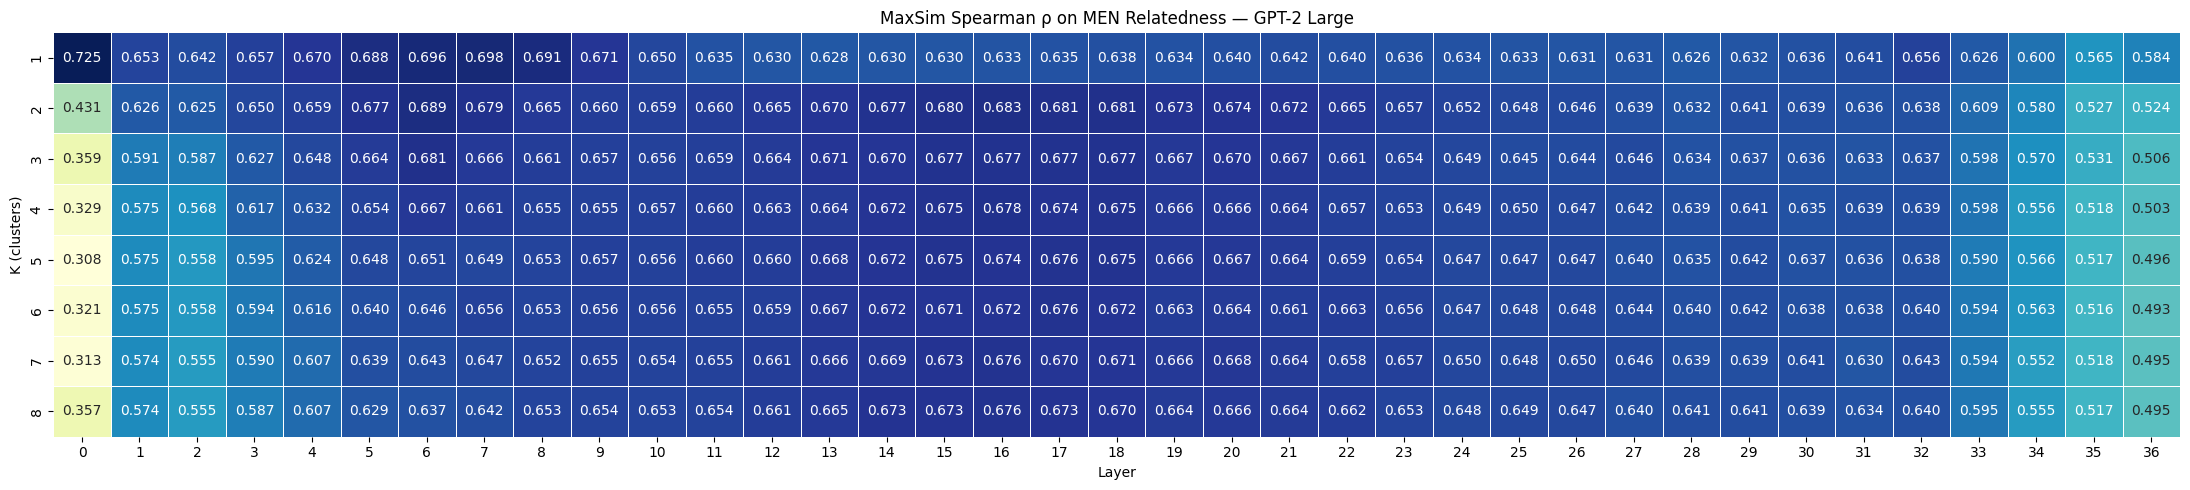

In [9]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)
GPT2_MEN_CSV = 'results/results_gpt2_men.csv'

if os.path.exists(GPT2_MEN_CSV):
    df_heat_men = pd.read_csv(GPT2_MEN_CSV, index_col=0)
    df_heat_men.columns = df_heat_men.columns.astype(int)
    print(f"Loaded {GPT2_MEN_CSV}")
else:
    K_values = [1, 2, 3, 4, 5, 6, 7, 8]

    heatmap_data_men = []
    for K in tqdm(K_values, desc="K values"):
        for layer_idx in tqdm(range(NUM_LAYERS + 1), desc=f"K={K} layers", leave=False):
            model_scores = [max_sim(w1, w2, layer_idx, K=K, outputs=all_layer_outputs_individual_combined)
                            for w1, w2 in men_valid_pairs]
            rho, _ = spearmanr(model_scores, men_human_sims)
            heatmap_data_men.append({'k_clusters': K, 'layer': layer_idx, 'spearman': round(rho, 3)})

    df_heat_men = pd.DataFrame(heatmap_data_men).pivot(index='k_clusters', columns='layer', values='spearman')
    df_heat_men.to_csv(GPT2_MEN_CSV)
    print(f"Saved {GPT2_MEN_CSV}")

fig, ax = plt.subplots(figsize=(22, 5))
sns.heatmap(df_heat_men, annot=True, fmt='.3f', linewidths=0.5, ax=ax, cmap='YlGnBu', square=False, cbar=False)
ax.set_title('MaxSim Spearman ρ on MEN Relatedness — GPT-2 Large')
ax.set_xlabel('Layer')
ax.set_ylabel('K (clusters)')
plt.tight_layout()
plt.savefig('results/gpt2_men_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Comparison with simple contextualized embeddings

In [18]:
# Simple contextualized embeddings: "The {} is here."
TEMPLATE = "The {} is here."
SIMPLE_PKL = 'simple_template_embeddings_gpt2.pkl'

def embed_words_simple(wordlist, model, tokenizer, template=TEMPLATE):
    embeddings = {}
    for word in tqdm(wordlist, desc="Embedding words"):
        sentence = template.format(word)
        enc = tokenizer(sentence, return_tensors="pt", return_offsets_mapping=True)
        offset_mapping = enc.pop("offset_mapping")[0]

        word_start = sentence.index(word)
        word_end = word_start + len(word)
        indices = [
            idx for idx, (tok_s, tok_e) in enumerate(offset_mapping.tolist())
            if tok_s < word_end and tok_e > word_start and tok_s < tok_e
        ]
        if not indices:
            continue

        inputs = {k: v.to(model.device) for k, v in enc.items()}
        with torch.no_grad():
            output = model(**inputs, output_hidden_states=True)

        layer_vecs = torch.stack([
            layer_hidden[0, indices, :].mean(dim=0).cpu()
            for layer_hidden in output.hidden_states
        ])
        embeddings[word] = layer_vecs
    return embeddings

if os.path.exists(SIMPLE_PKL):
    with open(SIMPLE_PKL, 'rb') as f:
        simple_embeddings = pickle.load(f)
    print(f"Loaded {SIMPLE_PKL}: {len(simple_embeddings)} words")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    simple_embeddings = embed_words_simple(all_words, model, tokenizer)
    with open(SIMPLE_PKL, 'wb') as f:
        pickle.dump(simple_embeddings, f)
    print(f"Saved {SIMPLE_PKL}")

Loaded simple_template_embeddings_gpt2.pkl: 1552 words


### SimLex-999

Per-layer Spearman ρ using the simple template embedding. Cached to `results_gpt2_simple_simlex.csv`.

Loaded results_gpt2_simple_simlex.csv


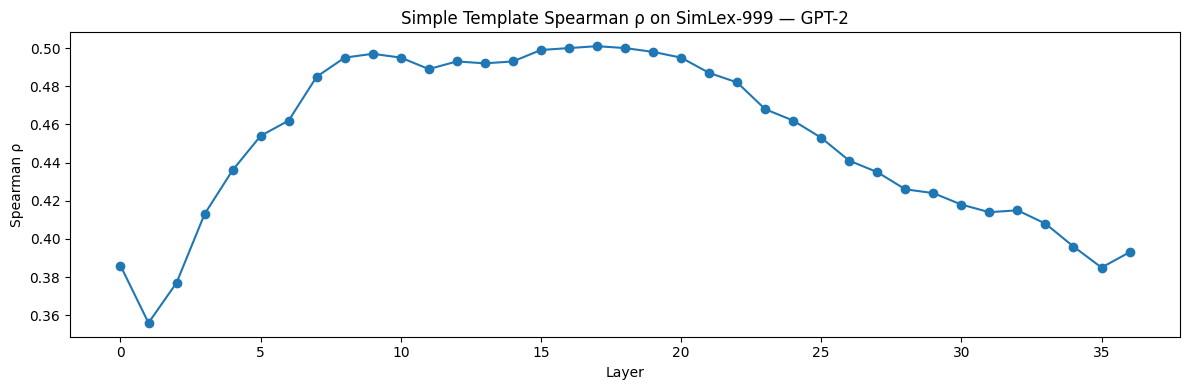

In [19]:
SIMPLE_SIMLEX_CSV = 'results/results_gpt2_simple_simlex.csv'

if os.path.exists(SIMPLE_SIMLEX_CSV):
    df_simple_simlex = pd.read_csv(SIMPLE_SIMLEX_CSV, index_col=0)
    print(f"Loaded {SIMPLE_SIMLEX_CSV}")
else:
    valid_pairs_simple = [
        (row['word1'], row['word2'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple = [
        float(row['SimLex999'])
        for row in simlex999
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid pairs: {len(valid_pairs_simple)}/999")

    results = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple)
        results.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_simlex = pd.DataFrame(results).set_index('layer')
    df_simple_simlex.to_csv(SIMPLE_SIMLEX_CSV)
    print(f"Saved {SIMPLE_SIMLEX_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_simlex.index, df_simple_simlex['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on SimLex-999 — GPT-2')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

### MEN

Per-layer Spearman ρ on MEN relatedness. Cached to `results_gpt2_simple_men.csv`.

Loaded results_gpt2_simple_men.csv


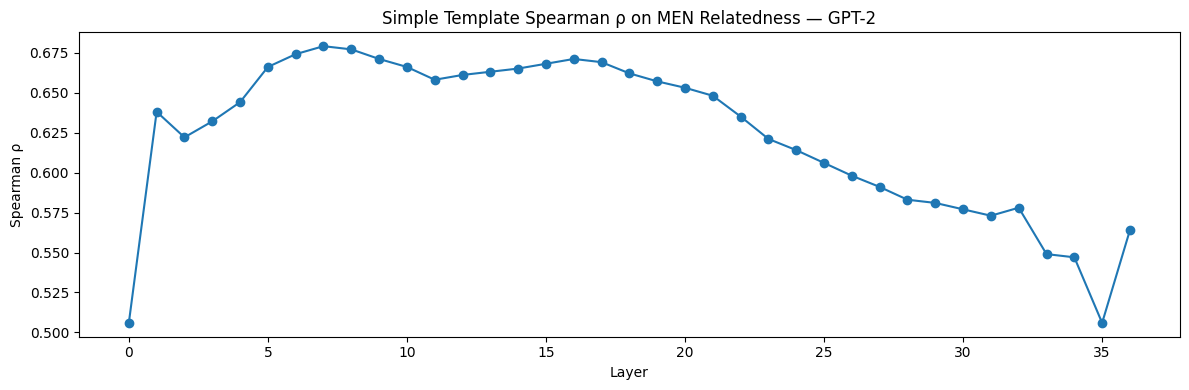

In [20]:
SIMPLE_MEN_CSV = 'results/results_gpt2_simple_men.csv'

if os.path.exists(SIMPLE_MEN_CSV):
    df_simple_men = pd.read_csv(SIMPLE_MEN_CSV, index_col=0)
    print(f"Loaded {SIMPLE_MEN_CSV}")
else:
    valid_pairs_simple_men = [
        (row['word1'], row['word2'])
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    human_sims_simple_men = [
        row['relatedness']
        for row in men
        if row['word1'] in simple_embeddings and row['word2'] in simple_embeddings
    ]
    print(f"Valid MEN pairs: {len(valid_pairs_simple_men)}/3000")

    results_men = []
    for layer_idx in tqdm(range(NUM_LAYERS + 1), desc="Layers"):
        model_scores = [
            float(torch.nn.functional.cosine_similarity(
                simple_embeddings[w1][layer_idx].unsqueeze(0),
                simple_embeddings[w2][layer_idx].unsqueeze(0)
            ))
            for w1, w2 in valid_pairs_simple_men
        ]
        rho, _ = spearmanr(model_scores, human_sims_simple_men)
        results_men.append({'layer': layer_idx, 'spearman': round(rho, 3)})

    df_simple_men = pd.DataFrame(results_men).set_index('layer')
    df_simple_men.to_csv(SIMPLE_MEN_CSV)
    print(f"Saved {SIMPLE_MEN_CSV}")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_simple_men.index, df_simple_men['spearman'], marker='o')
ax.set_title('Simple Template Spearman ρ on MEN Relatedness — GPT-2')
ax.set_xlabel('Layer')
ax.set_ylabel('Spearman ρ')
plt.tight_layout()
plt.show()

## Non-contextual Baselines

Each word is embedded in isolation (no surrounding context). Two variants:
- **Layer 0** (`hidden_states[0]`): token embedding before any transformer layers
- **Final layer** (`last_hidden_state`): full model pass with no context

Spearman ρ against SimLex-999 and MEN. Results saved to `results_gpt2_nonctx.csv`.

In [21]:
NONCTX_CSV = 'results/results_gpt2_nonctx.csv'

if os.path.exists(NONCTX_CSV):
    df_nonctx = pd.read_csv(NONCTX_CSV, index_col=0)
    print(f"Loaded {NONCTX_CSV}")
else:
    all_words = list(set(simlex999_wordlist + men_wordlist))
    initial_embs, final_embs = {}, {}

    for word in tqdm(all_words, desc="Non-contextual embeddings"):
        inputs = tokenizer(word, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model(**inputs, output_hidden_states=True)
        initial_embs[word] = out.hidden_states[0][0].mean(dim=0).float().cpu()
        final_embs[word] = out.last_hidden_state[0].mean(dim=0).float().cpu()

    def _spearman_cosine(embs, dataset, score_field):
        sims, human = [], []
        for r in dataset:
            w1, w2 = r['word1'], r['word2']
            if w1 in embs and w2 in embs:
                sims.append(torch.nn.functional.cosine_similarity(
                    embs[w1].unsqueeze(0), embs[w2].unsqueeze(0)
                ).item())
                human.append(float(r[score_field]))
        rho, _ = spearmanr(sims, human)
        return round(rho, 4)

    df_nonctx = pd.DataFrame([
        {'embedding': 'initial_layer_0',
         'simlex_rho': _spearman_cosine(initial_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(initial_embs, men, 'relatedness')},
        {'embedding': 'final_layer',
         'simlex_rho': _spearman_cosine(final_embs, simlex999, 'SimLex999'),
         'men_rho':    _spearman_cosine(final_embs, men, 'relatedness')},
    ]).set_index('embedding')
    df_nonctx.to_csv(NONCTX_CSV)
    print(f"Saved {NONCTX_CSV}")

display(df_nonctx)

Non-contextual embeddings:   0%|          | 0/1552 [00:00<?, ?it/s]

Saved results_gpt2_nonctx.csv


,simlex_rho,men_rho
embedding,,
initial_layer_0,0.0952,0.1081
final_layer,0.0940,0.3332
